In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def img_transform_square(path, dim):
    """
    EVD requires a square matrix, so we force the image to be dim x dim.
    """
    img = Image.open(path).convert('L')
    img = img.resize((dim, dim))
    return np.asarray(img, dtype=np.float64)

Image shape: (250, 250)


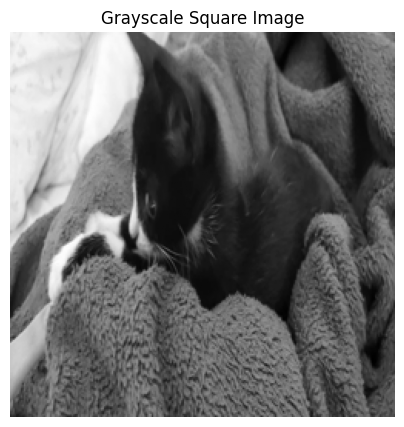

In [2]:
IMAGE_PATH = 'cat_14_svd_evd.png'  # Make sure this image is in your directory
dimm = 250
A = img_transform_square(IMAGE_PATH, dimm)
m, n = A.shape
print('Image shape:', A.shape)

plt.figure(figsize=(5,5))
plt.imshow(A, cmap='gray')
plt.title('Grayscale Square Image')
plt.axis('off')
plt.show()

In [3]:
def outer_prod(u, v):
    # to reconstruct Ak, q * p^T
    return u.reshape(-1, 1) * v.reshape(1, -1)

def frobenius_norm(M):
    # Frobenius norm to measure reconstruction error
    return np.sqrt(np.sum(np.abs(M) ** 2))

def creat_evd(A):
    """
    Finds Eigenvalues, Q, and Q_inv for the image matrix.
    """
    eigvals, Q = np.linalg.eig(A)                  # find eigenvalues and eigenvectors
    order = np.argsort(np.abs(eigvals))[::-1]      # sort by absolute magnitude of eigenvalues

    eigvals = eigvals[order]                       # order eigenvalues
    Q = Q[:, order]                                # order eigenvectors accordingly
    Q_inv = np.linalg.inv(Q)                       # compute the inverse of Q

    return eigvals, Q, Q_inv

In [4]:
# Compute EVD
eigvals, Q, Q_inv = creat_evd(A)
print('Q:', Q.shape, ' Eigenvalues:', eigvals.shape, ' Q_inv:', Q_inv.shape)
print('Top 10 eigenvalues (magnitude):', np.round(np.abs(eigvals[:10]), 2))

Q: (250, 250)  Eigenvalues: (250,)  Q_inv: (250, 250)
Top 10 eigenvalues (magnitude): [24006.12  2637.79  2637.79  2089.71  1350.88  1350.88   955.38   784.97
   784.97   735.74]


k=010   Frobenius error E(k) = 6895.134
k=040   Frobenius error E(k) = 4778.357
k=080   Frobenius error E(k) = 2952.736


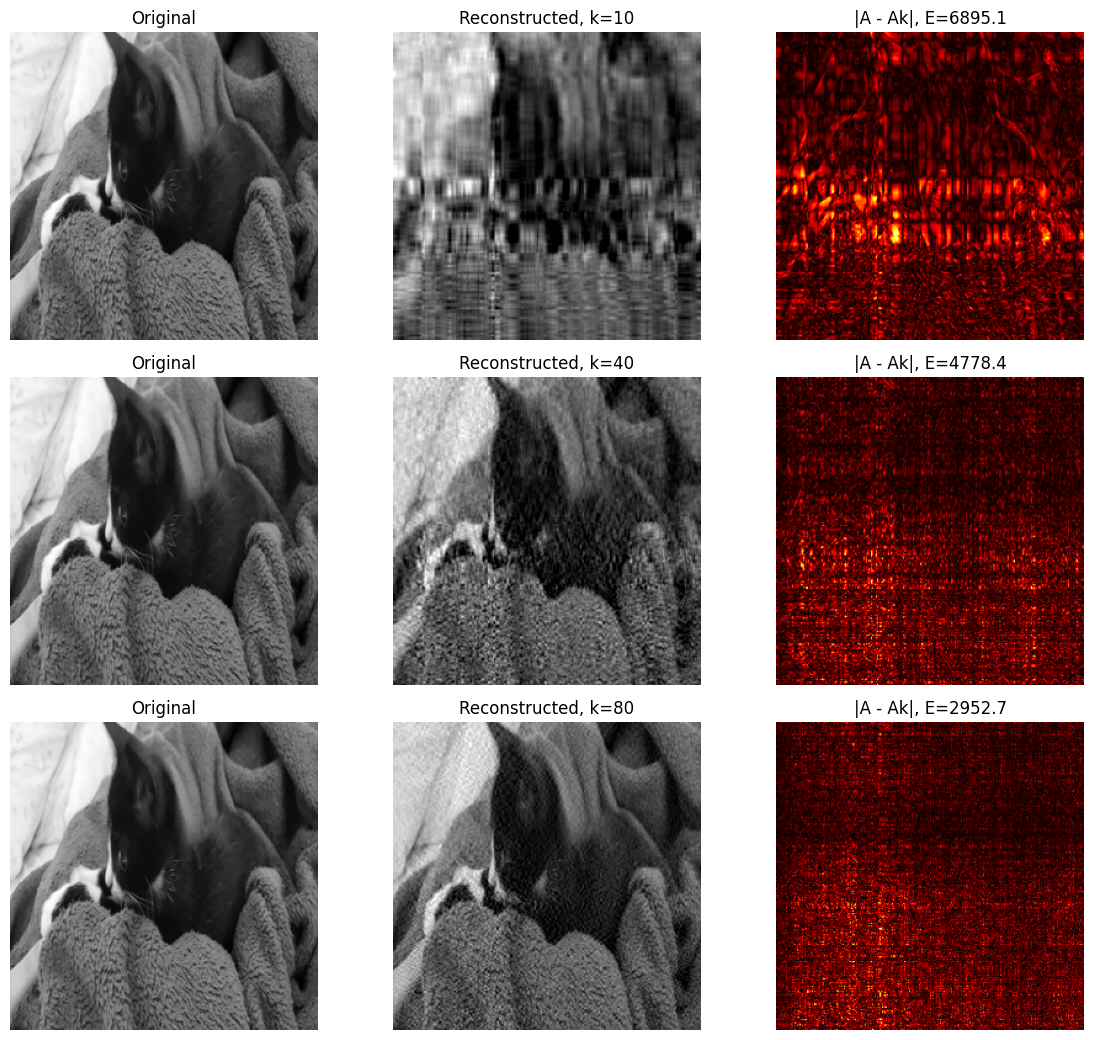

In [5]:
def reconstruct_evd(eigvals, Q, Q_inv, k):
    """
    Ak = sum_{i=1}^{k} lambda_i * outer(Q[:,i], Q_inv[i,:])
    """
    n = len(eigvals)
    # EVD calculations involve complex numbers, so we initialize Ak as complex
    Ak = np.zeros((n, n), dtype=complex)

    # Handle conjugate pairs: if we cut off halfway through a pair, add the conjugate
    if 0 < k < n and np.isclose(eigvals[k], np.conj(eigvals[k - 1])):
        k += 1

    for i in range(k):
        # Q[:, i] is the i-th column of Q
        # Q_inv[i, :] is the i-th row of Q_inv
        Ak += eigvals[i] * outer_prod(Q[:, i], Q_inv[i, :])

    # The image must be real, so we discard negligible imaginary floating-point artifacts
    return np.real(Ak)

max_k = n
k_values = (10, 40, 80)
k_values = [min(k, max_k) for k in k_values]

# Visualizing Specific K Values
fig, axes = plt.subplots(len(k_values), 3, figsize=(12, 3.5*len(k_values)))
for row, k in enumerate(k_values):
    Ak = reconstruct_evd(eigvals, Q, Q_inv, k)
    err = np.abs(A - Ak)
    E = frobenius_norm(A - Ak)
    print(f'k={k:03d}   Frobenius error E(k) = {E:.3f}')

    axes[row,0].imshow(A, cmap='gray')
    axes[row,0].set_title('Original')

    axes[row,1].imshow(np.clip(Ak, 0, 255), cmap='gray')
    axes[row,1].set_title(f'Reconstructed, k={k}')

    axes[row,2].imshow(err, cmap='hot')
    axes[row,2].set_title(f'|A - Ak|, E={E:.1f}')

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.show()

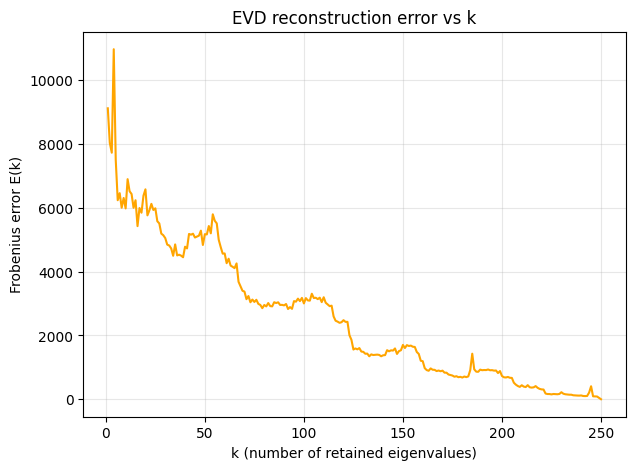

In [6]:
E_all = np.zeros(max_k)
Ak_running = np.zeros((n, n), dtype=complex)

for i in range(max_k):
    # Iteratively add the next principal component
    Ak_running = Ak_running + eigvals[i] * outer_prod(Q[:, i], Q_inv[i, :])

    # Calculate error against the real part
    E_all[i] = frobenius_norm(A - np.real(Ak_running))

plt.figure(figsize=(7,5))
plt.plot(np.arange(1, max_k+1), E_all, color='orange')
plt.xlabel('k (number of retained eigenvalues)')
plt.ylabel('Frobenius error E(k)')
plt.title('EVD reconstruction error vs k')
plt.grid(True, alpha=0.3)
plt.show()